# 구조물 안정성 예측 - EDA

목표:
1. 라벨 분포 확인 (train/dev)
2. 이미지 해상도/특성 확인
3. Train vs Dev 도메인 차이 분석
4. Stable vs Unstable 시각적 패턴 비교
5. 시뮬레이션 영상 기본 정보 확인

In [1]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import os

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data')
print(f'Data directory: {DATA_DIR.resolve()}')
print(f'Exists: {DATA_DIR.exists()}')

Data directory: C:\Users\jungj\Desktop\structural-stability-prediction\data
Exists: True


## 1. 라벨 분포

In [2]:
train_df = pd.read_csv(DATA_DIR / 'train.csv')
dev_df = pd.read_csv(DATA_DIR / 'dev.csv')
sub_df = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print('=== Train ===' )
print(f'Total: {len(train_df)}')
print(train_df['label'].value_counts())
print(f'Unstable ratio: {(train_df["label"]=="unstable").mean():.3f}')
print()
print('=== Dev ===')
print(f'Total: {len(dev_df)}')
print(dev_df['label'].value_counts())
print(f'Unstable ratio: {(dev_df["label"]=="unstable").mean():.3f}')
print()
print('=== Combined (Train+Dev) ===')
all_labels = pd.concat([train_df, dev_df])
print(f'Total: {len(all_labels)}')
print(all_labels['label'].value_counts())
print(f'Unstable ratio: {(all_labels["label"]=="unstable").mean():.3f}')
print()
print('=== Test (submission format) ===')
print(f'Total: {len(sub_df)}')
print(sub_df.head())

=== Train ===
Total: 1000
label
unstable    500
stable      500
Name: count, dtype: int64
Unstable ratio: 0.500

=== Dev ===
Total: 100
label
unstable    52
stable      48
Name: count, dtype: int64
Unstable ratio: 0.520

=== Combined (Train+Dev) ===
Total: 1100
label
unstable    552
stable      548
Name: count, dtype: int64
Unstable ratio: 0.502

=== Test (submission format) ===
Total: 1000
          id  unstable_prob  stable_prob
0  TEST_0001            0.0          1.0
1  TEST_0002            0.0          1.0
2  TEST_0003            0.0          1.0
3  TEST_0004            0.0          1.0
4  TEST_0005            0.0          1.0


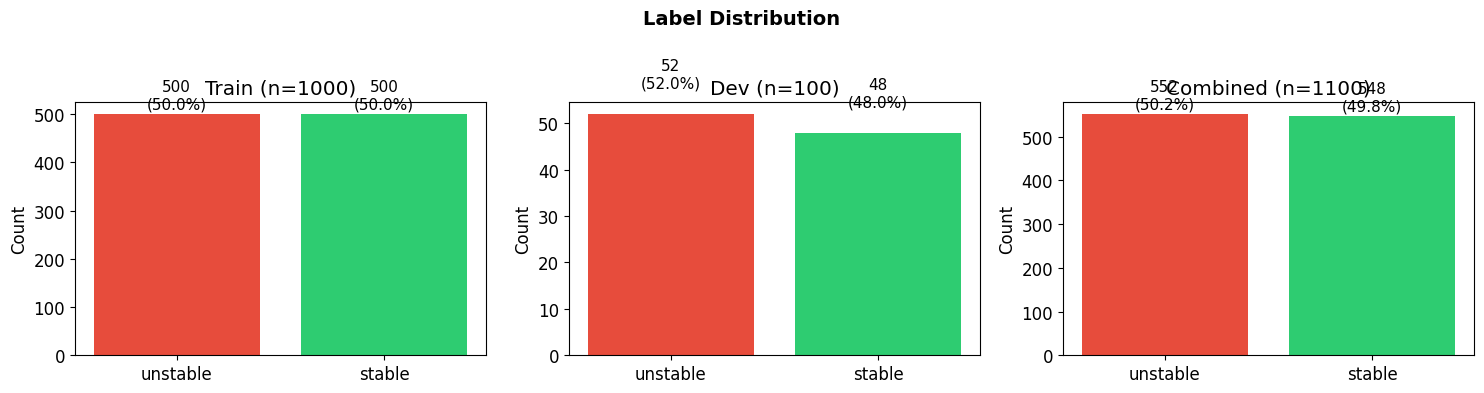

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Train', train_df), ('Dev', dev_df), ('Combined', all_labels)]):
    counts = df['label'].value_counts()
    colors = ['#e74c3c' if l == 'unstable' else '#2ecc71' for l in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f'{name} (n={len(df)})')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)

plt.suptitle('Label Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. 이미지 해상도/채널 확인

In [4]:
# 각 split에서 이미지 해상도 샘플링
def check_image_stats(split_dir, sample_ids, view='front'):
    sizes = []
    for sid in sample_ids:
        img_path = split_dir / sid / f'{view}.png'
        if img_path.exists():
            img = cv2.imread(str(img_path))
            if img is not None:
                sizes.append((img.shape[1], img.shape[0], img.shape[2]))
    return sizes

# Train
train_ids = train_df['id'].tolist()
train_front_sizes = check_image_stats(DATA_DIR / 'train', train_ids[:50], 'front')
train_top_sizes = check_image_stats(DATA_DIR / 'train', train_ids[:50], 'top')

# Dev
dev_ids = dev_df['id'].tolist()
dev_front_sizes = check_image_stats(DATA_DIR / 'dev', dev_ids[:50], 'front')
dev_top_sizes = check_image_stats(DATA_DIR / 'dev', dev_ids[:50], 'top')

# Test
test_ids = sub_df['id'].tolist()
test_front_sizes = check_image_stats(DATA_DIR / 'test', test_ids[:50], 'front')
test_top_sizes = check_image_stats(DATA_DIR / 'test', test_ids[:50], 'top')

print('=== Image Sizes (W, H, C) ===')
for name, sizes in [('Train front', train_front_sizes), ('Train top', train_top_sizes),
                     ('Dev front', dev_front_sizes), ('Dev top', dev_top_sizes),
                     ('Test front', test_front_sizes), ('Test top', test_top_sizes)]:
    unique = Counter(sizes)
    print(f'{name:12s}: {dict(unique)}')

=== Image Sizes (W, H, C) ===
Train front : {(384, 384, 3): 50}
Train top   : {(384, 384, 3): 50}
Dev front   : {(384, 384, 3): 50}
Dev top     : {(384, 384, 3): 50}
Test front  : {(384, 384, 3): 50}
Test top    : {(384, 384, 3): 50}


## 3. Stable vs Unstable 시각적 비교

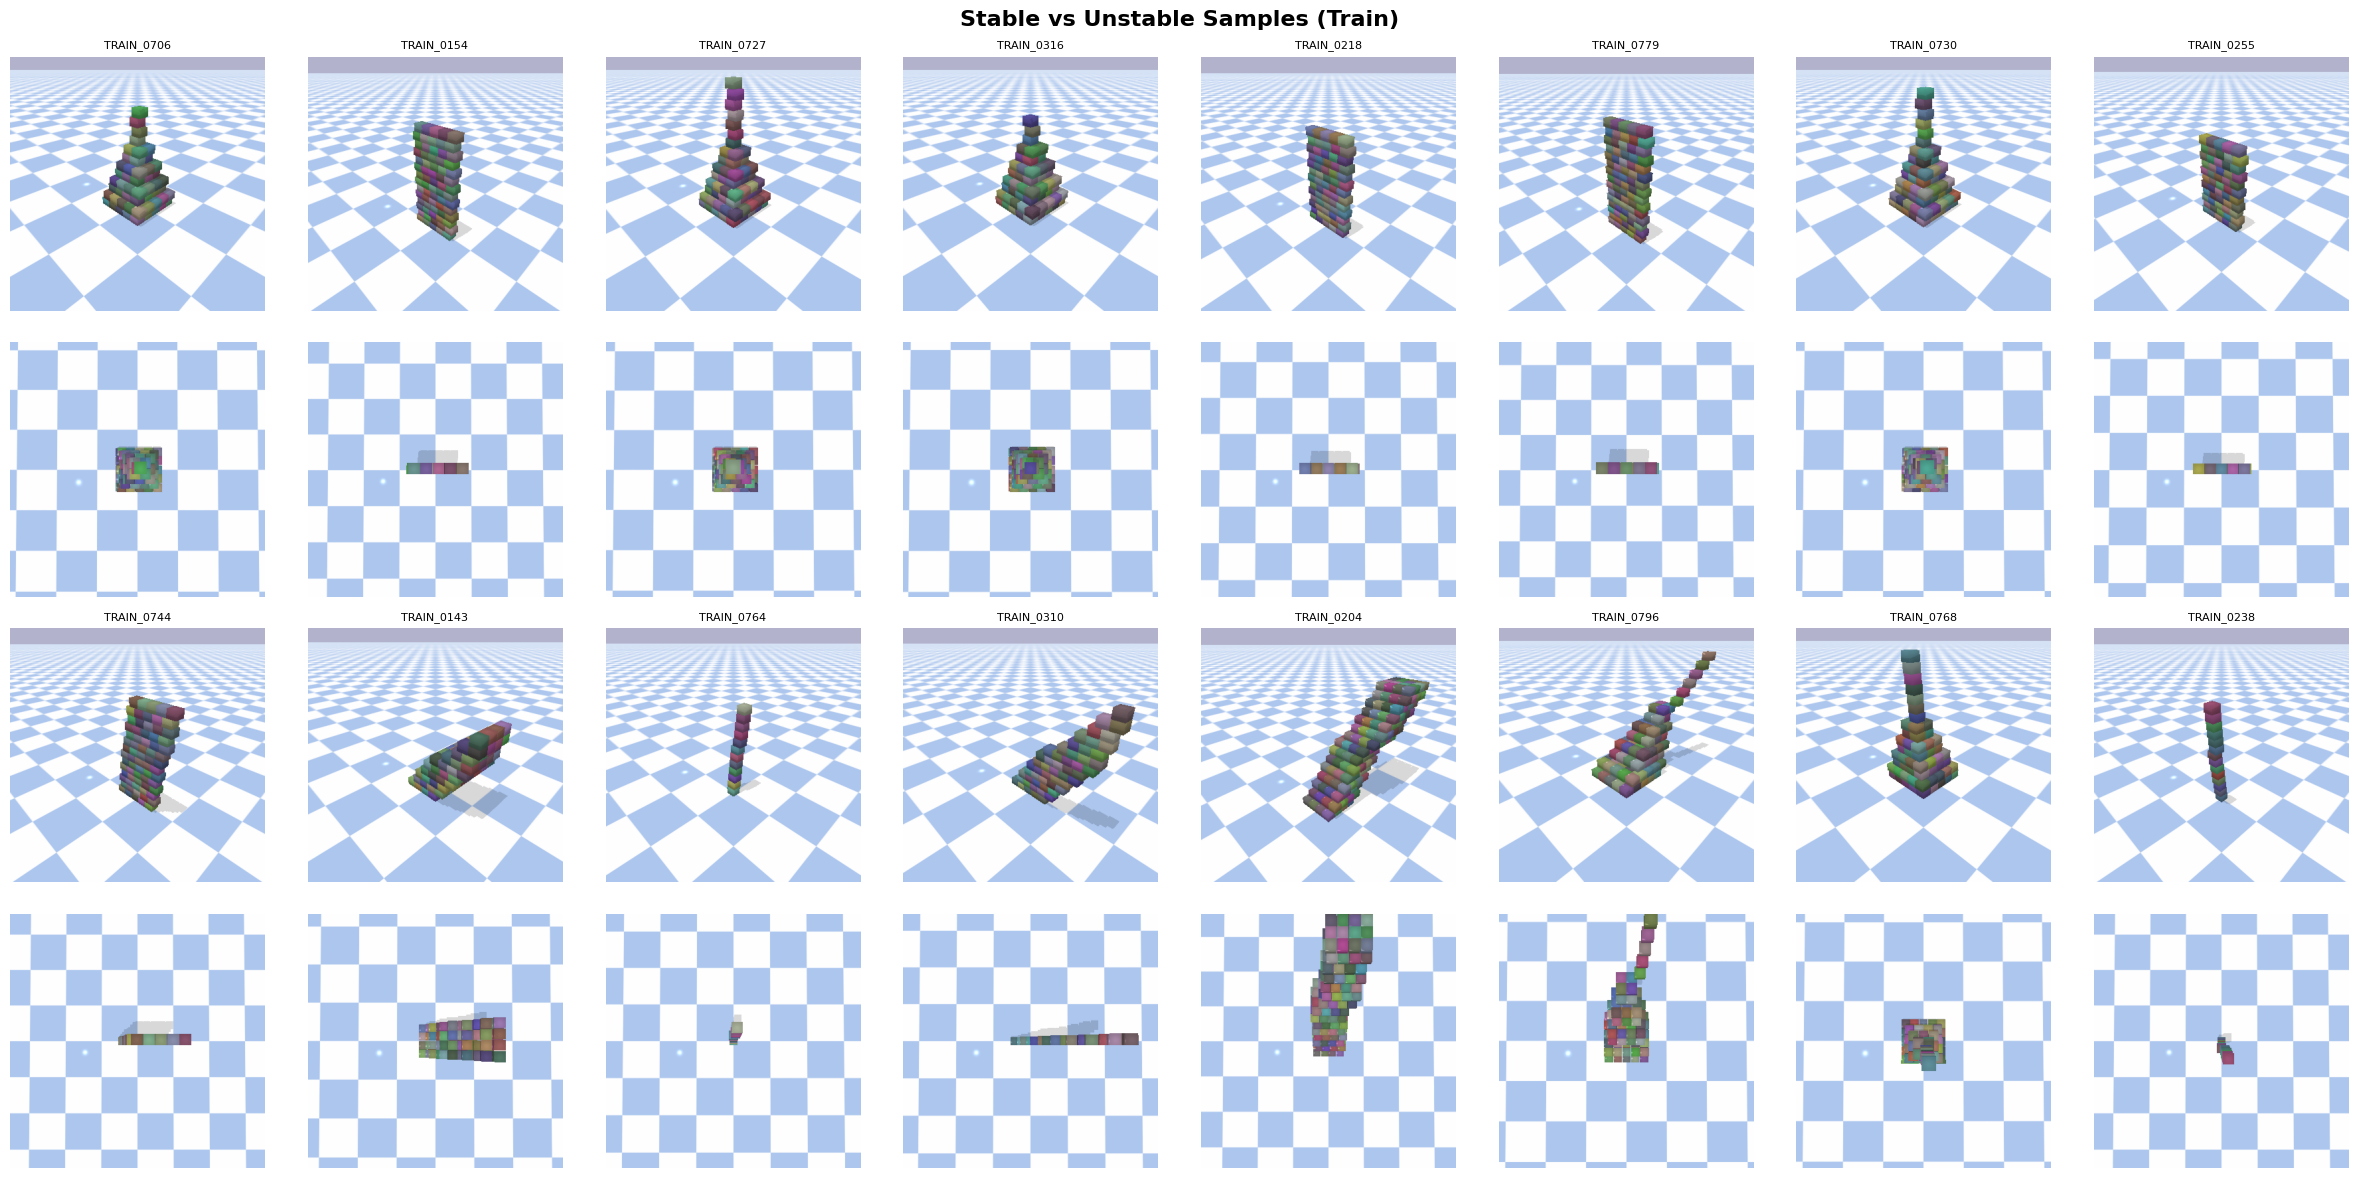

In [5]:
def load_sample(data_dir, sample_id):
    front = cv2.imread(str(data_dir / sample_id / 'front.png'))
    front = cv2.cvtColor(front, cv2.COLOR_BGR2RGB)
    top = cv2.imread(str(data_dir / sample_id / 'top.png'))
    top = cv2.cvtColor(top, cv2.COLOR_BGR2RGB)
    return front, top

# Stable 샘플 8개
stable_ids = train_df[train_df['label'] == 'stable']['id'].sample(8, random_state=42).tolist()
# Unstable 샘플 8개
unstable_ids = train_df[train_df['label'] == 'unstable']['id'].sample(8, random_state=42).tolist()

fig, axes = plt.subplots(4, 8, figsize=(24, 12))

for col, sid in enumerate(stable_ids):
    front, top = load_sample(DATA_DIR / 'train', sid)
    axes[0, col].imshow(front)
    axes[0, col].set_title(f'{sid}', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(top)
    axes[1, col].axis('off')

for col, sid in enumerate(unstable_ids):
    front, top = load_sample(DATA_DIR / 'train', sid)
    axes[2, col].imshow(front)
    axes[2, col].set_title(f'{sid}', fontsize=8)
    axes[2, col].axis('off')
    axes[3, col].imshow(top)
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('STABLE\nFront', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[1, 0].set_ylabel('STABLE\nTop', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[2, 0].set_ylabel('UNSTABLE\nFront', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[3, 0].set_ylabel('UNSTABLE\nTop', fontsize=12, fontweight='bold', rotation=0, labelpad=60)

plt.suptitle('Stable vs Unstable Samples (Train)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Train vs Dev 도메인 차이 분석 (핵심!)

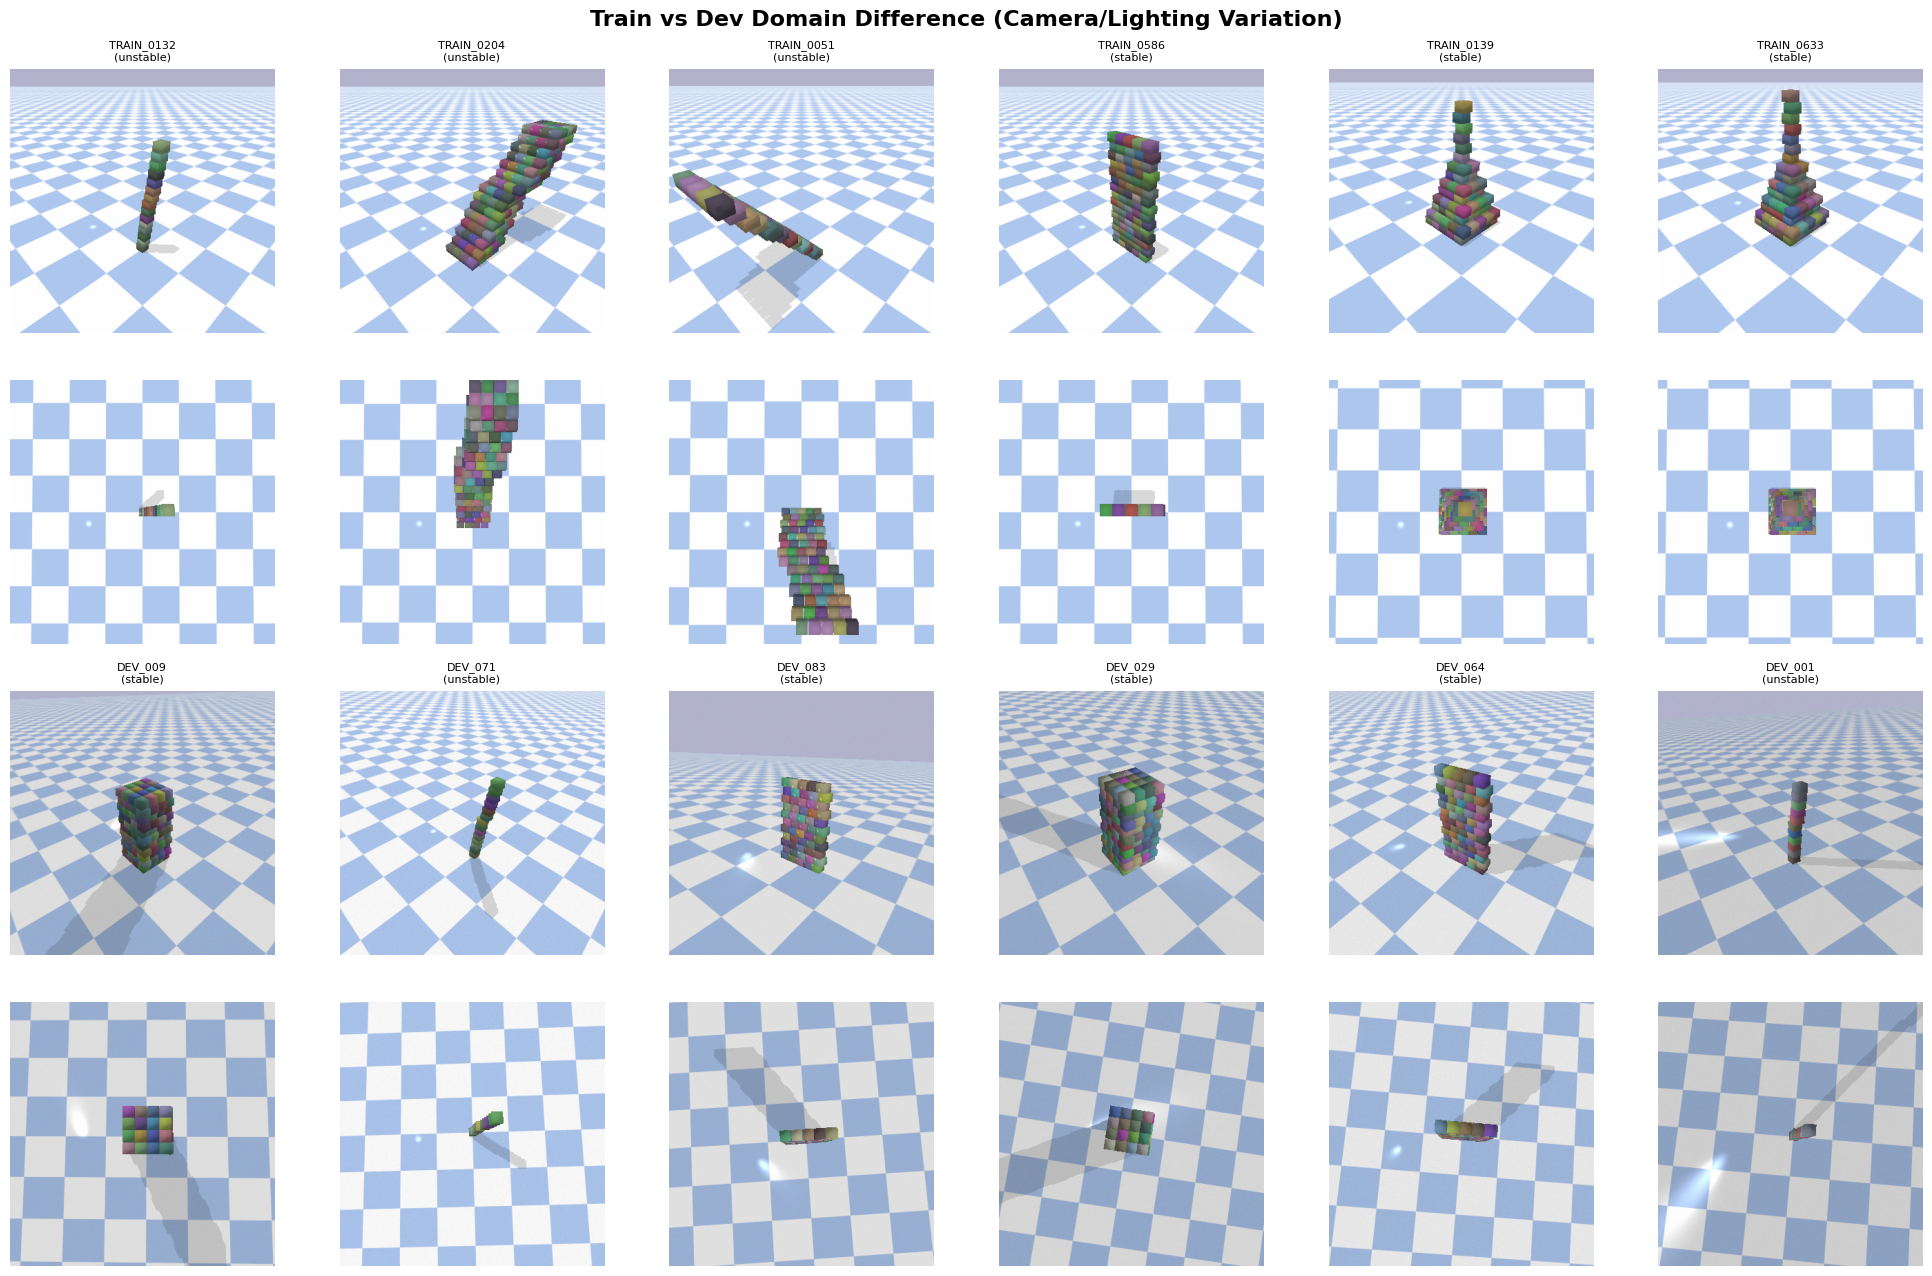

In [6]:
# Train과 Dev 이미지를 나란히 비교
train_samples = train_df['id'].sample(6, random_state=123).tolist()
dev_samples = dev_df['id'].sample(6, random_state=123).tolist()

fig, axes = plt.subplots(4, 6, figsize=(20, 13))

for col, sid in enumerate(train_samples):
    front, top = load_sample(DATA_DIR / 'train', sid)
    label = train_df[train_df['id'] == sid]['label'].values[0]
    axes[0, col].imshow(front)
    axes[0, col].set_title(f'{sid}\n({label})', fontsize=8)
    axes[0, col].axis('off')
    axes[1, col].imshow(top)
    axes[1, col].axis('off')

for col, sid in enumerate(dev_samples):
    front, top = load_sample(DATA_DIR / 'dev', sid)
    label = dev_df[dev_df['id'] == sid]['label'].values[0]
    axes[2, col].imshow(front)
    axes[2, col].set_title(f'{sid}\n({label})', fontsize=8)
    axes[2, col].axis('off')
    axes[3, col].imshow(top)
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('TRAIN\nFront', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[1, 0].set_ylabel('TRAIN\nTop', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[2, 0].set_ylabel('DEV\nFront', fontsize=12, fontweight='bold', rotation=0, labelpad=60)
axes[3, 0].set_ylabel('DEV\nTop', fontsize=12, fontweight='bold', rotation=0, labelpad=60)

plt.suptitle('Train vs Dev Domain Difference (Camera/Lighting Variation)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

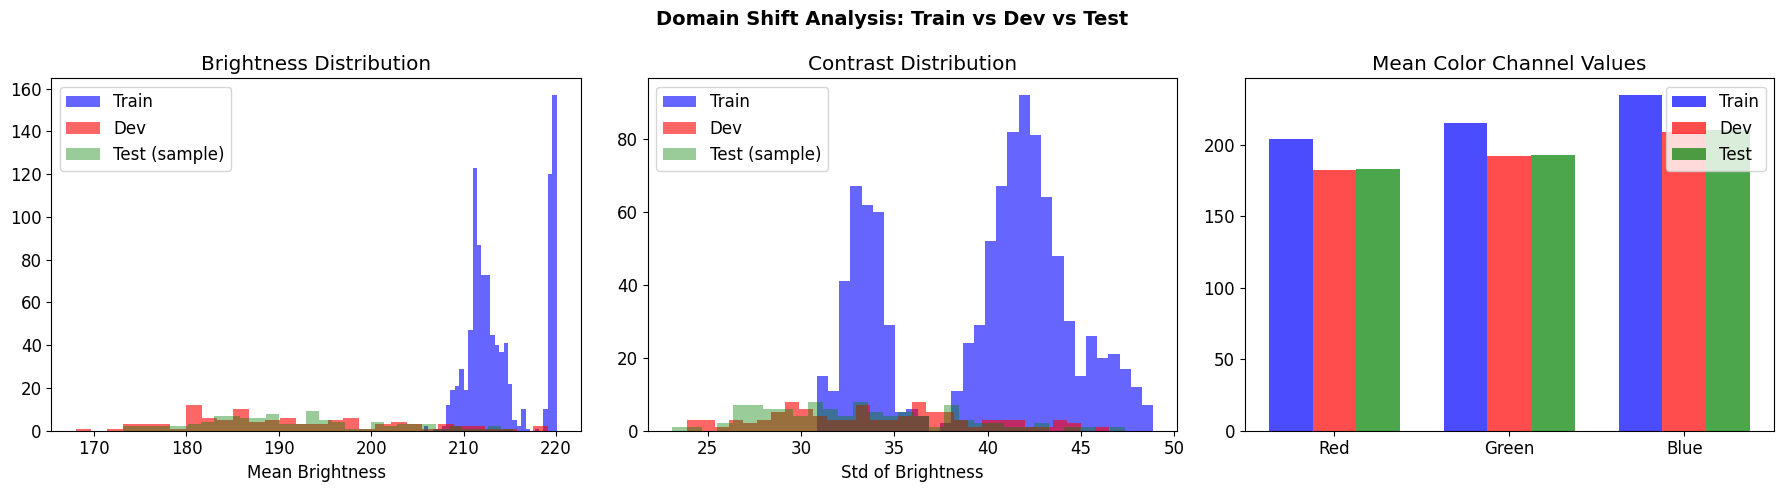

=== Summary ===
Train | Brightness: 214.2 ± 3.7 | Contrast: 39.8 ± 4.6 | RGB: [203.9, 215.4, 234.5]
Dev   | Brightness: 190.9 ± 11.2 | Contrast: 33.9 ± 5.4 | RGB: [182.0, 191.9, 209.1]
Test  | Brightness: 191.7 ± 9.8 | Contrast: 32.9 ± 5.0 | RGB: [182.9, 192.7, 209.8]


In [7]:
# 도메인 차이 정량 분석: 밝기/대비/색상 분포 비교
def compute_image_stats(data_dir, sample_ids, view='front'):
    brightness_list = []
    contrast_list = []
    color_means = []  # R, G, B

    for sid in sample_ids:
        img_path = data_dir / sid / f'{view}.png'
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        brightness_list.append(gray.mean())
        contrast_list.append(gray.std())
        color_means.append(img_rgb.mean(axis=(0, 1)))

    return {
        'brightness': np.array(brightness_list),
        'contrast': np.array(contrast_list),
        'color_means': np.array(color_means)
    }

train_stats = compute_image_stats(DATA_DIR / 'train', train_df['id'].tolist(), 'front')
dev_stats = compute_image_stats(DATA_DIR / 'dev', dev_df['id'].tolist(), 'front')

# Test도 확인
test_stats = compute_image_stats(DATA_DIR / 'test', sub_df['id'].tolist()[:100], 'front')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 밝기 분포
axes[0].hist(train_stats['brightness'], bins=30, alpha=0.6, label='Train', color='blue')
axes[0].hist(dev_stats['brightness'], bins=30, alpha=0.6, label='Dev', color='red')
axes[0].hist(test_stats['brightness'], bins=30, alpha=0.4, label='Test (sample)', color='green')
axes[0].set_title('Brightness Distribution')
axes[0].set_xlabel('Mean Brightness')
axes[0].legend()

# 대비 분포
axes[1].hist(train_stats['contrast'], bins=30, alpha=0.6, label='Train', color='blue')
axes[1].hist(dev_stats['contrast'], bins=30, alpha=0.6, label='Dev', color='red')
axes[1].hist(test_stats['contrast'], bins=30, alpha=0.4, label='Test (sample)', color='green')
axes[1].set_title('Contrast Distribution')
axes[1].set_xlabel('Std of Brightness')
axes[1].legend()

# 색상 채널별 평균
channels = ['Red', 'Green', 'Blue']
x = np.arange(3)
w = 0.25
axes[2].bar(x - w, train_stats['color_means'].mean(axis=0), w, label='Train', color='blue', alpha=0.7)
axes[2].bar(x, dev_stats['color_means'].mean(axis=0), w, label='Dev', color='red', alpha=0.7)
axes[2].bar(x + w, test_stats['color_means'].mean(axis=0), w, label='Test', color='green', alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels(channels)
axes[2].set_title('Mean Color Channel Values')
axes[2].legend()

plt.suptitle('Domain Shift Analysis: Train vs Dev vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Summary ===')
for name, stats in [('Train', train_stats), ('Dev', dev_stats), ('Test', test_stats)]:
    print(f'{name:5s} | Brightness: {stats["brightness"].mean():.1f} ± {stats["brightness"].std():.1f} | '
          f'Contrast: {stats["contrast"].mean():.1f} ± {stats["contrast"].std():.1f} | '
          f'RGB: [{stats["color_means"].mean(axis=0)[0]:.1f}, {stats["color_means"].mean(axis=0)[1]:.1f}, {stats["color_means"].mean(axis=0)[2]:.1f}]')

## 5. 구조물 크기/형태 분석

In [8]:
def extract_structure_features(data_dir, sample_id):
    """구조물 영역을 분리하고 기본적인 형태 특징을 추출"""
    front = cv2.imread(str(data_dir / sample_id / 'front.png'))
    top = cv2.imread(str(data_dir / sample_id / 'top.png'))
    if front is None or top is None:
        return None

    # 체커보드 배경과 구조물 분리 (HSV 기반)
    # 배경은 흰색/연파란색 체커보드 → 채도가 낮고 밝기가 높음
    # 구조물은 다양한 색상의 블록 → 채도가 상대적으로 높음
    hsv = cv2.cvtColor(front, cv2.COLOR_BGR2HSV)
    
    # 구조물 마스크: 채도가 일정 수준 이상이거나 밝기가 낮은 영역
    sat_mask = hsv[:, :, 1] > 30  # 채도 기반
    val_mask = hsv[:, :, 2] < 180  # 밝기 기반 (어두운 부분)
    structure_mask = (sat_mask | val_mask).astype(np.uint8)
    
    # 노이즈 제거
    kernel = np.ones((5, 5), np.uint8)
    structure_mask = cv2.morphologyEx(structure_mask, cv2.MORPH_CLOSE, kernel)
    structure_mask = cv2.morphologyEx(structure_mask, cv2.MORPH_OPEN, kernel)

    # Bounding box
    coords = np.where(structure_mask > 0)
    if len(coords[0]) == 0:
        return None
    
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    height = y_max - y_min
    width = x_max - x_min

    # Top view도 분석
    hsv_top = cv2.cvtColor(top, cv2.COLOR_BGR2HSV)
    top_mask = (hsv_top[:, :, 1] > 30).astype(np.uint8)
    top_mask = cv2.morphologyEx(top_mask, cv2.MORPH_CLOSE, kernel)
    top_area = top_mask.sum()

    return {
        'id': sample_id,
        'front_height': height,
        'front_width': width,
        'aspect_ratio': height / max(width, 1),
        'front_area': structure_mask.sum(),
        'top_area': top_area,
        'center_x': (x_min + x_max) / 2 / front.shape[1],  # 정규화된 중심
        'center_y': (y_min + y_max) / 2 / front.shape[0],
    }

# Train 전체에서 특징 추출
features = []
for sid in train_df['id'].tolist():
    feat = extract_structure_features(DATA_DIR / 'train', sid)
    if feat is not None:
        features.append(feat)

feat_df = pd.DataFrame(features)
feat_df = feat_df.merge(train_df, on='id')

print(f'Features extracted: {len(feat_df)} / {len(train_df)}')
feat_df.head()

Features extracted: 1000 / 1000


,id,front_height,front_width,aspect_ratio,front_area,top_area,center_x,center_y,label
0,TRAIN_0001,383,383,1.0,98740,77735,0.498698,0.498698,unstable
1,TRAIN_0002,383,383,1.0,96655,75473,0.498698,0.498698,unstable
2,TRAIN_0003,383,383,1.0,91075,74277,0.498698,0.498698,unstable
3,TRAIN_0004,383,383,1.0,93219,74294,0.498698,0.498698,unstable
4,TRAIN_0005,383,383,1.0,91345,74245,0.498698,0.498698,stable


C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 45908 (\N{HANGUL SYLLABLE DEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\3202053465.py:22: UserWarning: Glyph 45458 (\N{HANGUL SYLLABLE NOP}) missing from fo

C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-predicti

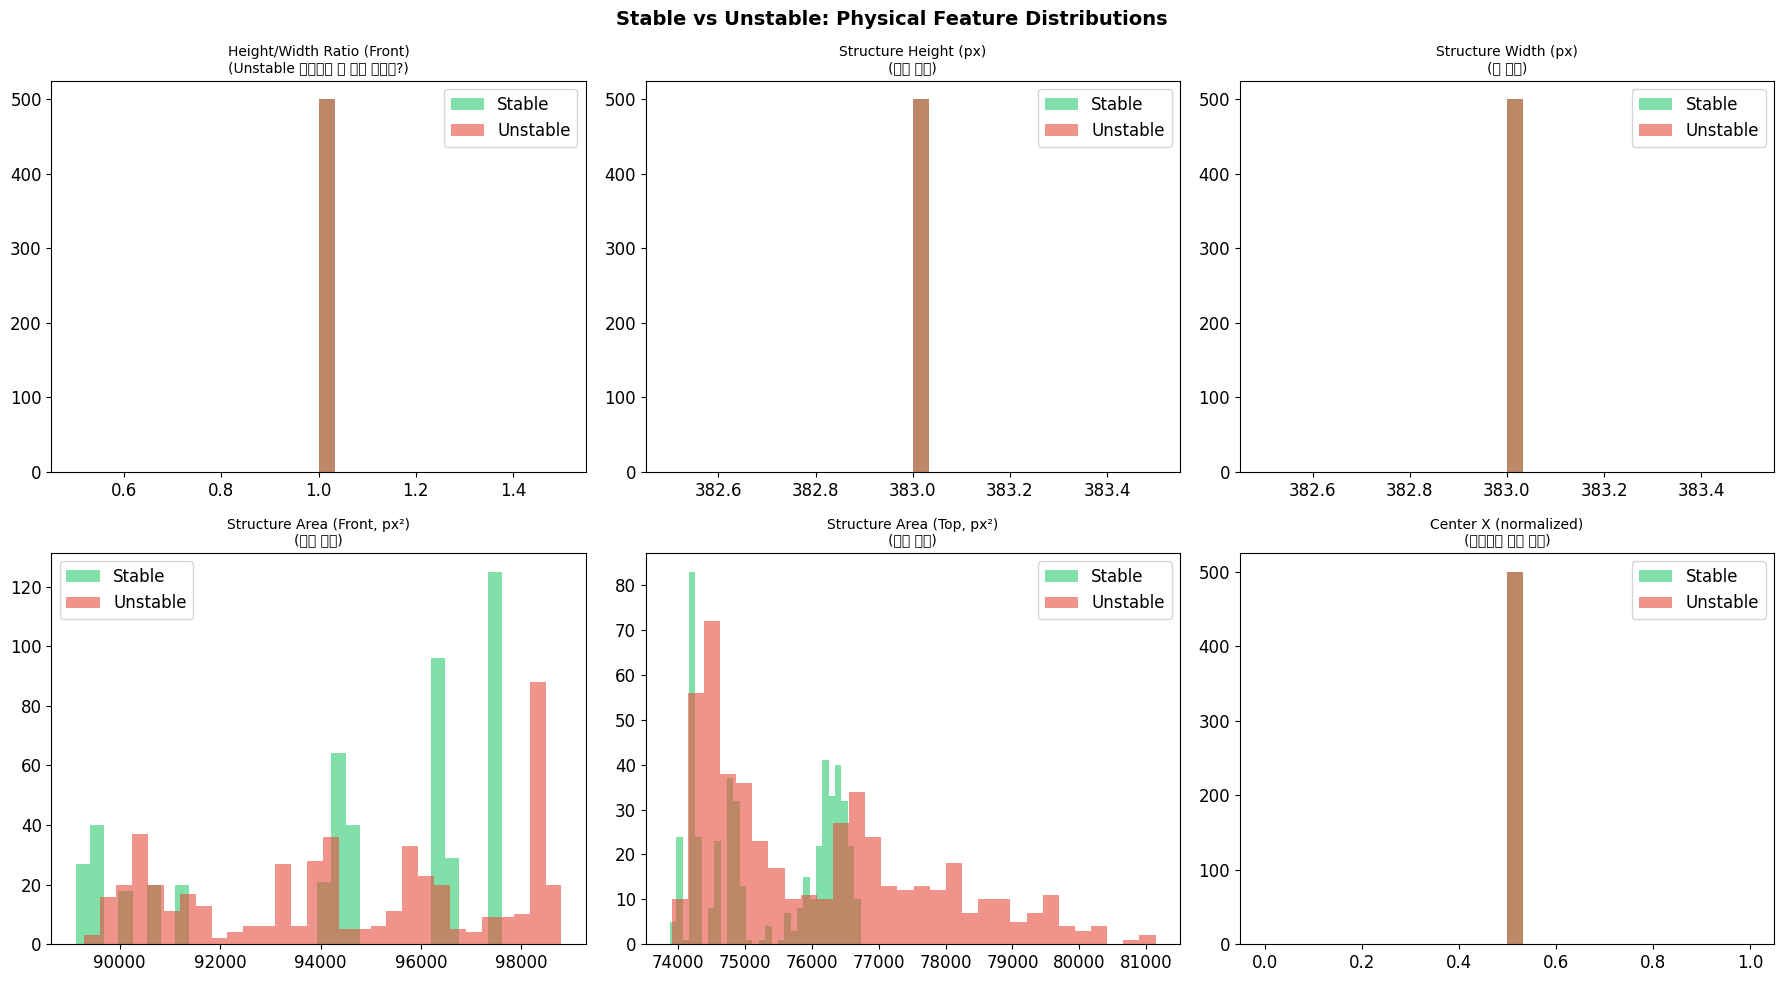

=== Feature Statistics by Label ===
aspect_ratio    | Stable:      1.0 | Unstable:      1.0 | Diff: +0.0%
front_height    | Stable:    383.0 | Unstable:    383.0 | Diff: +0.0%
front_width     | Stable:    383.0 | Unstable:    383.0 | Diff: +0.0%
front_area      | Stable:  94564.5 | Unstable:  94549.2 | Diff: -0.0%
top_area        | Stable:  75351.2 | Unstable:  76079.7 | Diff: +1.0%


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

stable_feat = feat_df[feat_df['label'] == 'stable']
unstable_feat = feat_df[feat_df['label'] == 'unstable']

metrics = [
    ('aspect_ratio', 'Height/Width Ratio (Front)', 'Unstable 구조물이 더 높고 좁은가?'),
    ('front_height', 'Structure Height (px)', '높이 분포'),
    ('front_width', 'Structure Width (px)', '폭 분포'),
    ('front_area', 'Structure Area (Front, px²)', '전면 면적'),
    ('top_area', 'Structure Area (Top, px²)', '상면 면적'),
    ('center_x', 'Center X (normalized)', '무게중심 수평 편향'),
]

for ax, (col, title, desc) in zip(axes.flat, metrics):
    ax.hist(stable_feat[col], bins=30, alpha=0.6, label='Stable', color='#2ecc71')
    ax.hist(unstable_feat[col], bins=30, alpha=0.6, label='Unstable', color='#e74c3c')
    ax.set_title(f'{title}\n({desc})', fontsize=10)
    ax.legend()

plt.suptitle('Stable vs Unstable: Physical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 통계 요약
print('=== Feature Statistics by Label ===')
for col in ['aspect_ratio', 'front_height', 'front_width', 'front_area', 'top_area']:
    s_mean = stable_feat[col].mean()
    u_mean = unstable_feat[col].mean()
    print(f'{col:15s} | Stable: {s_mean:8.1f} | Unstable: {u_mean:8.1f} | Diff: {(u_mean-s_mean)/s_mean*100:+.1f}%')

## 6. 시뮬레이션 영상 분석

In [10]:
# 영상 기본 정보 확인
sample_video = str(DATA_DIR / 'train' / 'TRAIN_0001' / 'simulation.mp4')
cap = cv2.VideoCapture(sample_video)

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps if fps > 0 else 0

print(f'Video: {sample_video}')
print(f'FPS: {fps}')
print(f'Frame count: {frame_count}')
print(f'Resolution: {width}x{height}')
print(f'Duration: {duration:.1f}s')
cap.release()

# 여러 영상의 fps/해상도 일관성 확인
print('\n=== Checking consistency across videos ===')
video_infos = []
for sid in train_df['id'].sample(20, random_state=42).tolist():
    vpath = str(DATA_DIR / 'train' / sid / 'simulation.mp4')
    c = cv2.VideoCapture(vpath)
    video_infos.append({
        'id': sid,
        'fps': c.get(cv2.CAP_PROP_FPS),
        'frames': int(c.get(cv2.CAP_PROP_FRAME_COUNT)),
        'width': int(c.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int(c.get(cv2.CAP_PROP_FRAME_HEIGHT)),
    })
    c.release()

vi_df = pd.DataFrame(video_infos)
print(vi_df.describe())

Video: ..\data\train\TRAIN_0001\simulation.mp4
FPS: 30.0
Frame count: 300
Resolution: 384x384
Duration: 10.0s

=== Checking consistency across videos ===
        fps  frames  width  height
count  20.0    20.0   20.0    20.0
mean   30.0   300.0  384.0   384.0
std     0.0     0.0    0.0     0.0
min    30.0   300.0  384.0   384.0
25%    30.0   300.0  384.0   384.0
50%    30.0   300.0  384.0   384.0
75%    30.0   300.0  384.0   384.0
max    30.0   300.0  384.0   384.0


C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\997344082.py:49: UserWarning: Glyph 48533 (\N{HANGUL SYLLABLE BUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\997344082.py:49: UserWarning: Glyph 44340 (\N{HANGUL SYLLABLE GOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\997344082.py:49: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\997344082.py:49: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48533 (\N{HANGUL SYLLABLE BUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-

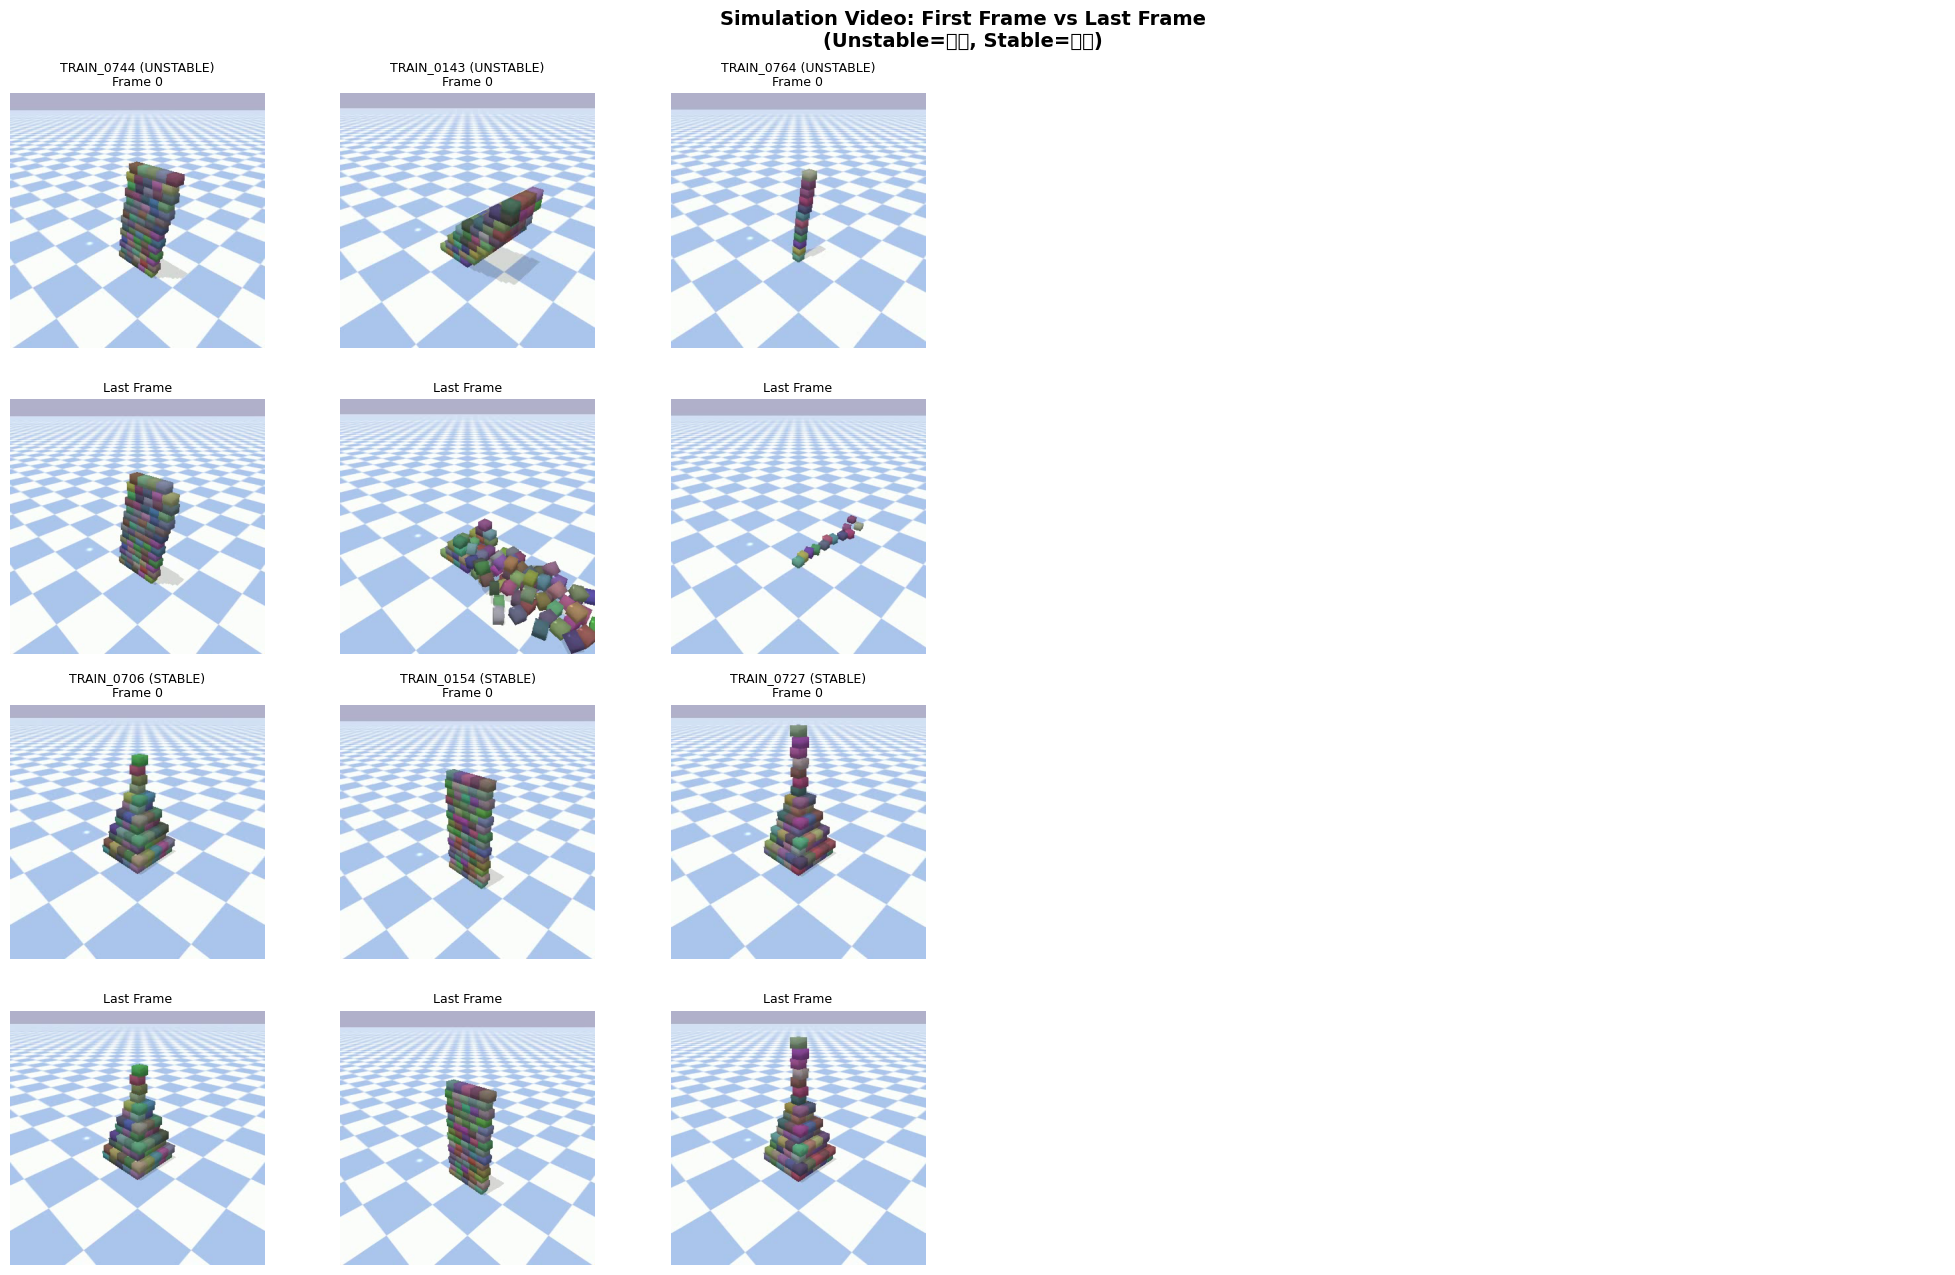

In [11]:
# Stable vs Unstable 영상의 첫/마지막 프레임 비교
def get_video_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    for idx in frame_indices:
        actual_idx = idx if idx >= 0 else total + idx
        cap.set(cv2.CAP_PROP_POS_FRAMES, actual_idx)
        ret, frame = cap.read()
        if ret:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        else:
            frames.append(np.zeros((100, 100, 3), dtype=np.uint8))
    cap.release()
    return frames

# Unstable 3개, Stable 3개
unstable_video_ids = train_df[train_df['label'] == 'unstable']['id'].sample(3, random_state=42).tolist()
stable_video_ids = train_df[train_df['label'] == 'stable']['id'].sample(3, random_state=42).tolist()

fig, axes = plt.subplots(4, 6, figsize=(20, 13))

for col, sid in enumerate(unstable_video_ids):
    vpath = DATA_DIR / 'train' / sid / 'simulation.mp4'
    first, last = get_video_frames(vpath, [0, -1])
    axes[0, col].imshow(first)
    axes[0, col].set_title(f'{sid} (UNSTABLE)\nFrame 0', fontsize=9)
    axes[0, col].axis('off')
    axes[1, col].imshow(last)
    axes[1, col].set_title('Last Frame', fontsize=9)
    axes[1, col].axis('off')

for col, sid in enumerate(stable_video_ids):
    vpath = DATA_DIR / 'train' / sid / 'simulation.mp4'
    first, last = get_video_frames(vpath, [0, -1])
    axes[2, col].imshow(first)
    axes[2, col].set_title(f'{sid} (STABLE)\nFrame 0', fontsize=9)
    axes[2, col].axis('off')
    axes[3, col].imshow(last)
    axes[3, col].set_title('Last Frame', fontsize=9)
    axes[3, col].axis('off')

# 나머지 열 비우기
for row in range(4):
    for col in range(3, 6):
        axes[row, col].axis('off')

plt.suptitle('Simulation Video: First Frame vs Last Frame\n(Unstable=붕괴, Stable=유지)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# 영상 기반 displacement 측정 (Soft Label 생성 가능성 검증)
def measure_displacement(video_path):
    """첫 프레임과 마지막 프레임 간 구조물 변위를 측정"""
    cap = cv2.VideoCapture(str(video_path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # 첫 프레임
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
    ret, first = cap.read()
    # 마지막 프레임
    cap.set(cv2.CAP_PROP_POS_FRAMES, total - 1)
    ret, last = cap.read()
    cap.release()

    if first is None or last is None:
        return None

    # 프레임 차이 (절대값)
    diff = cv2.absdiff(first, last)
    gray_diff = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)

    # 변화량 지표들
    mean_diff = gray_diff.mean()
    max_diff = gray_diff.max()
    changed_pixels = (gray_diff > 20).sum()  # threshold 20 이상 변화
    changed_ratio = changed_pixels / gray_diff.size

    return {
        'mean_diff': mean_diff,
        'max_diff': max_diff,
        'changed_pixels': changed_pixels,
        'changed_ratio': changed_ratio
    }

# 전체 Train에 대해 displacement 측정
displacements = []
for sid in train_df['id'].tolist():
    vpath = DATA_DIR / 'train' / sid / 'simulation.mp4'
    d = measure_displacement(vpath)
    if d is not None:
        d['id'] = sid
        displacements.append(d)

disp_df = pd.DataFrame(displacements).merge(train_df, on='id')
print(f'Displacement computed: {len(disp_df)} / {len(train_df)}')

Displacement computed: 1000 / 1000


C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\2431338968.py:15: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\2431338968.py:15: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\2431338968.py:15: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\AppData\Local\Temp\ipykernel_54100\2431338968.py:15: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\jungj\Desktop\structural-stability-prediction\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\jungj\Desktop\structural-stability-prediction\.ven

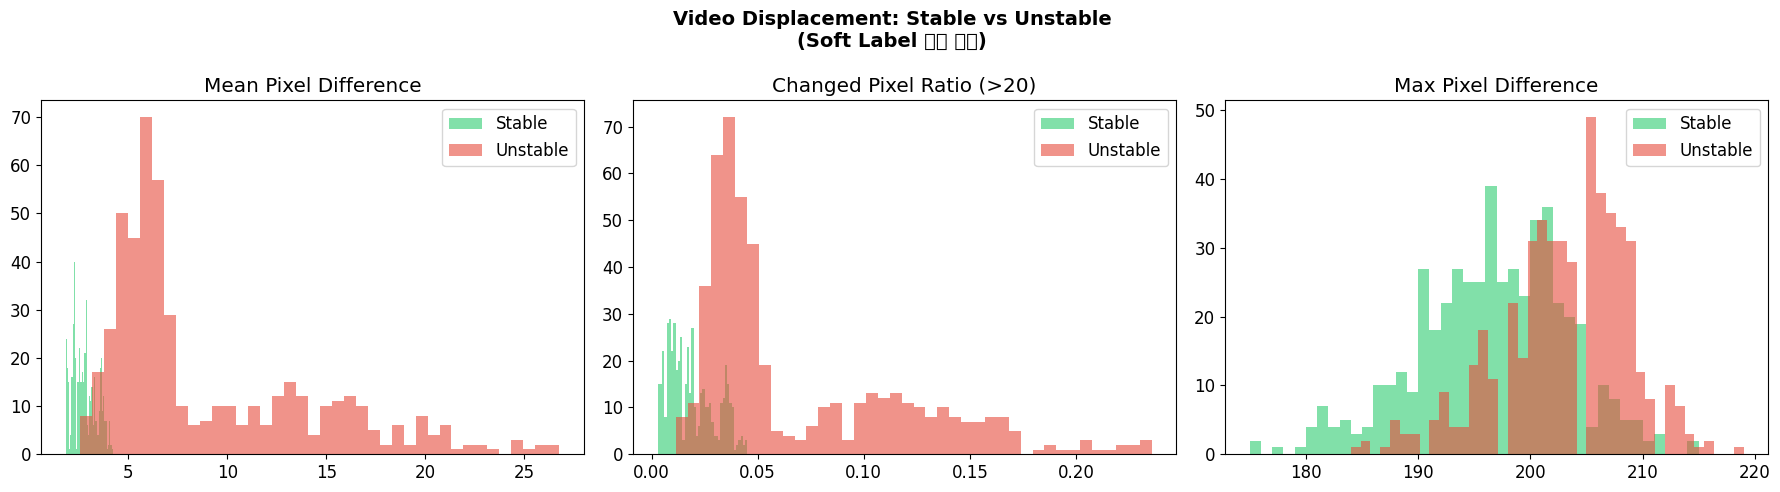

=== Displacement Statistics ===
mean_diff            | Stable: 2.7962 | Unstable: 9.0233 | Ratio: 3.2x
changed_ratio        | Stable: 0.0188 | Unstable: 0.0703 | Ratio: 3.7x


mean_diff            | AUC: 0.9861
changed_ratio        | AUC: 0.9233


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

stable_disp = disp_df[disp_df['label'] == 'stable']
unstable_disp = disp_df[disp_df['label'] == 'unstable']

for ax, col, title in zip(axes,
    ['mean_diff', 'changed_ratio', 'max_diff'],
    ['Mean Pixel Difference', 'Changed Pixel Ratio (>20)', 'Max Pixel Difference']):
    ax.hist(stable_disp[col], bins=40, alpha=0.6, label='Stable', color='#2ecc71')
    ax.hist(unstable_disp[col], bins=40, alpha=0.6, label='Unstable', color='#e74c3c')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Video Displacement: Stable vs Unstable\n(Soft Label 생성 근거)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 분리도 확인
print('=== Displacement Statistics ===')
for col in ['mean_diff', 'changed_ratio']:
    s_mean = stable_disp[col].mean()
    u_mean = unstable_disp[col].mean()
    print(f'{col:20s} | Stable: {s_mean:.4f} | Unstable: {u_mean:.4f} | Ratio: {u_mean/max(s_mean,1e-9):.1f}x')

# AUC: displacement만으로 stable/unstable 분류 가능한가?
from sklearn.metrics import roc_auc_score
y_true = (disp_df['label'] == 'unstable').astype(int)
for col in ['mean_diff', 'changed_ratio']:
    auc = roc_auc_score(y_true, disp_df[col])
    print(f'{col:20s} | AUC: {auc:.4f}')

## 7. EDA 결론

### 핵심 발견
1. **라벨 분포**: (위 결과 확인)
2. **이미지 해상도**: (위 결과 확인)
3. **도메인 차이**: Train vs Dev의 밝기/대비/색상 분포 차이 확인 → 증강 전략 근거
4. **구조적 특징**: aspect_ratio, 면적 등이 stable/unstable 분류에 유의미한 차이를 보이는지 확인
5. **영상 displacement**: AUC가 높을수록 soft label 생성의 근거가 됨

### 다음 단계
- Phase 0: 영상 기반 soft label 생성 (`video_preprocess.py`)
- Phase 1: 최강 단일 모델 구현 (위 분석 결과 반영)